In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

In [2]:
print("Antes de cargar dataset")

datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

print("Dataset cargado")

Antes de cargar dataset
Dataset cargado


In [3]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/Users/derekrodriguez/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DB

In [4]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [5]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
for i, nombre in enumerate(nombres_clases):
    print(i, nombre)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


In [7]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

2026-03-09 17:46:39.586340: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:376] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-03-09 17:46:39.589745: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:46:39.589850: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `datas

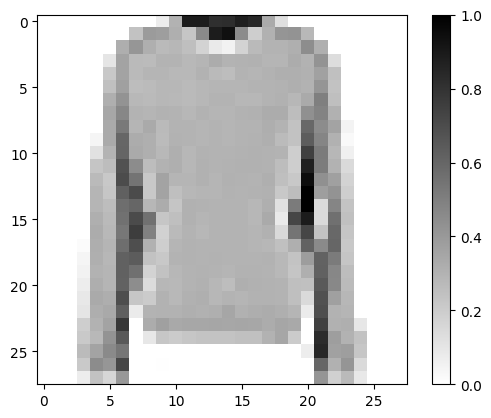

Etiqueta: Pullover


In [8]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break

imagen = imagen.numpy().reshape((28, 28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

print("Etiqueta:", nombres_clases[etiqueta])

2026-03-09 17:46:39.705600: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:46:39.705664: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:46:39.707991: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

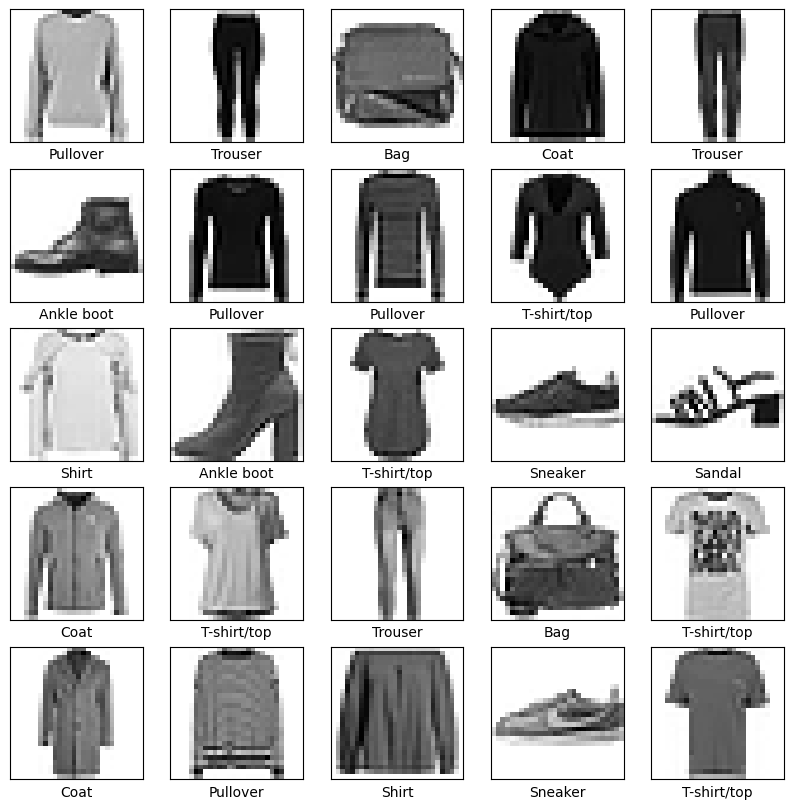

In [9]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28, 28))
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

In [10]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/opt/anaconda3/envs/mledu/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [12]:
TAMANO_LOTE = 32

num_ej_entrenamiento = metadatos.splits['train'].num_examples
num_ej_pruebas = metadatos.splits['test'].num_examples

print("Entrenamiento:", num_ej_entrenamiento)
print("Pruebas:", num_ej_pruebas)

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

Entrenamiento: 60000
Pruebas: 10000


In [13]:
historial = modelo.fit(
    datos_entrenamiento,
    epochs=5,
    steps_per_epoch=math.ceil(num_ej_entrenamiento / TAMANO_LOTE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 369us/step - accuracy: 0.7623 - loss: 0.7014
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 412us/step - accuracy: 0.8595 - loss: 0.3998
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 355us/step - accuracy: 0.8746 - loss: 0.3465
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 418us/step - accuracy: 0.8789 - loss: 0.3246
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 380us/step - accuracy: 0.8848 - loss: 0.3105


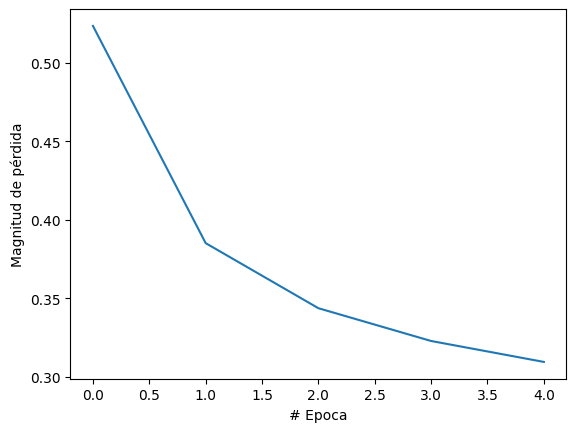

In [14]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.show()

In [15]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


2026-03-09 17:46:44.660882: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:46:44.660984: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:46:44.661143: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

In [16]:
def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)

    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(
        nombres_clases[etiqueta_prediccion],
        100*np.max(arr_predicciones),
        nombres_clases[etiqueta_real]),
        color=color
    )

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones)
    plt.ylim([0, 1])

    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

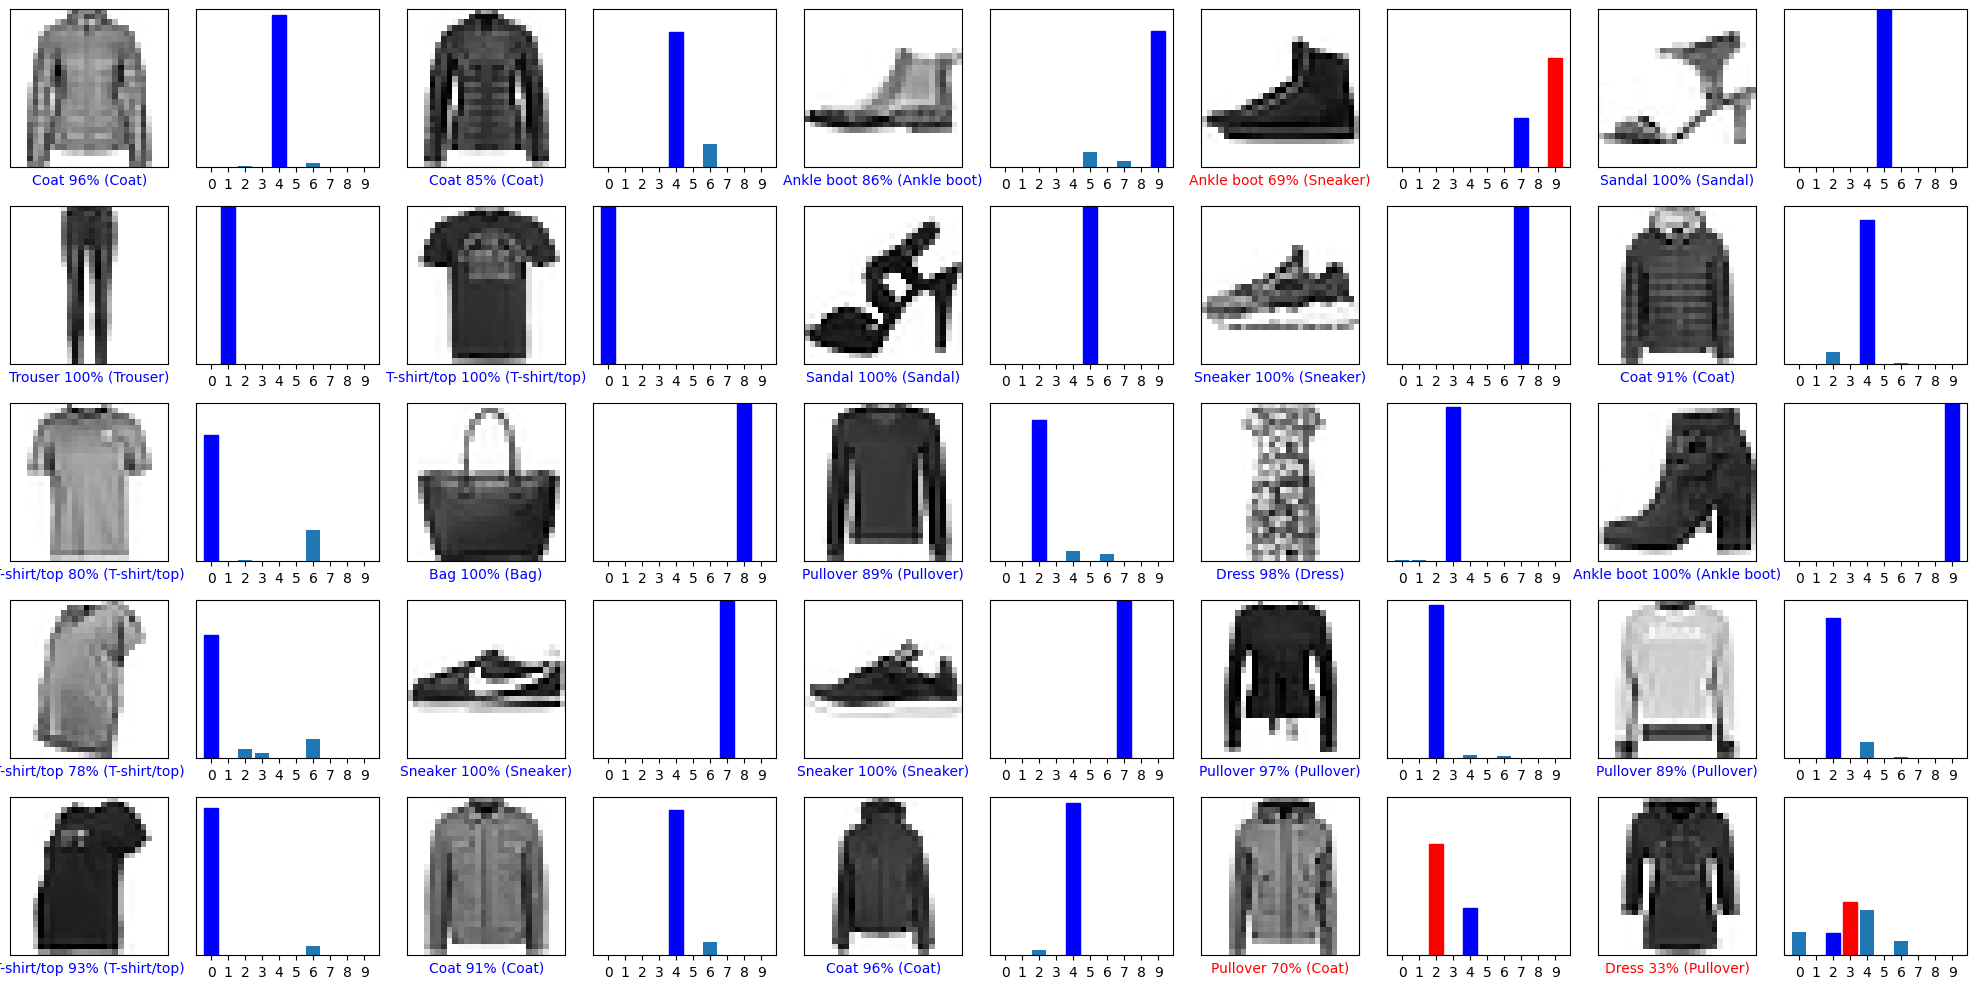

In [17]:
filas = 5
columnas = 5
num_imagenes = filas * columnas

plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)

    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

plt.tight_layout()
plt.show()

In [18]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])

prediccion = modelo.predict(imagen)

print("Predicción:", nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicción: Dress


### IMÁGEN DEL USUARIO

In [19]:
def preparar_imagen(ruta_imagen):
    img = Image.open(ruta_imagen).convert('L')   # escala de grises
    img = img.resize((28, 28))
    img_array = np.array(img).astype('float32')

    # Normalizar
    img_array = img_array / 255.0

    # Invertir colores si la imagen viene con fondo blanco y objeto oscuro
    # Fashion MNIST suele verse con ropa clara sobre fondo oscuro
    if np.mean(img_array) > 0.5:
        img_array = 1.0 - img_array

    # Mostrar imagen procesada
    plt.figure(figsize=(3,3))
    plt.imshow(img_array, cmap='gray')
    plt.title("Imagen procesada 28x28")
    plt.axis('off')
    plt.show()

    # Ajustar forma a (1,28,28,1)
    img_array = img_array.reshape(1, 28, 28, 1)
    return img_array

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

salida = widgets.Output()
uploader = widgets.FileUpload(accept='image/*', multiple=False)

display(uploader, salida)

def clasificar_imagen_subida(change):
    with salida:
        clear_output()
        
        if not uploader.value:
            return

        archivo = uploader.value[0]
        contenido = archivo["content"]

        with open("imagen_subida.png", "wb") as f:
            f.write(contenido)

        img_procesada = preparar_imagen("imagen_subida.png")
        pred = modelo.predict(img_procesada, verbose=0)

        indice = np.argmax(pred[0])
        print("Predicción:", nombres_clases[indice])
        print("Confianza: {:.2f}%".format(100 * np.max(pred[0])))

uploader.observe(clasificar_imagen_subida, names='value')

FileUpload(value=(), accept='image/*', description='Upload')

Output()

### Qué es el formato h5 y para qué sirve?
El .h5 es un formato de archivos para guardar el modelo entrenado y luego poder volver a cargarlo sin reentrenarlo.

In [21]:
modelo.save("modelo_tienda_ropa.h5")
print("Modelo guardado en formato .h5")

Modelo guardado en formato .h5
